# Firm characteristics: letting the characteristics choose the factors

Everything up to here has predicted the return from the characteristics directly - a linear
model in [`05_linear`](05_linear.ipynb), boosted trees in [`06_gbm`](06_gbm.ipynb), a network in
[`07_tabular_dl`](07_tabular_dl.ipynb). Each of the 57 columns got its own weight, and the fit
had to find those weights in one monthly cross-section at a time.

The latent-factor family asks a different question first. Suppose the cross-section of returns is
driven by a handful of common factors, and what a characteristic tells you is not the return but
**how exposed a firm is to those factors**. Then the thing to estimate is the map from
characteristics to exposures, and that map is shared by every firm and every month - so it is
estimated on the whole panel rather than on one month.

**Instrumented PCA** is the linear member of that family. Ordinary PCA takes the returns and
finds the directions that explain the most variance, which says nothing about characteristics at
all; and it needs a firm to be the same firm across the whole sample, which this panel's
anonymous split-scoped identities cannot promise. IPCA instead requires each firm's exposure to
be a linear function of its own characteristics that month, and fits the factor returns and that
linear map together. It is the designated linear characteristic-sorted baseline here, and
`config/training/{label}.yaml` declares no `pca` for that reason.

**Learning objectives**

- Distinguish estimating a return directly from estimating exposures that a factor return is
  then applied to.
- See why a model with no epochs still has a checkpoint, and what that checkpoint means.
- Read a population published for every declared label rather than the traded one.

**Book reference**: Chapter 14, Section 14.5 (Bridging economics and statistics with advanced
models). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run log this
notebook writes into.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_evaluation`](04_evaluation.ipynb) and [`08_latent_factors`](08_latent_factors.ipynb), which
introduces the family and says which of its four members each notebook publishes.

**What it writes**: one training run per label and one complete validation prediction set per
label, in `run_log/registry.db` and under `run_log/training/` and `run_log/predictions/`, grouped
under a population named for this model. The family splits across four notebooks, so each
publishes its own population rather than one shared one.
[`11_backtest`](11_backtest.ipynb) reads them and selects on validation backtest Sharpe.
**Selection happens there, not here.**

In [1]:
"""Fit the declared firm-characteristics IPCA population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    plan_models,
    planned_model_plan,
    primary_label,
    run_model_population,
)
from case_studies.us_firm_characteristics.research_workflow import MODEL_RUNTIME_OVERRIDES
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""

MODEL_NAME = "ipca"

In [3]:
study = open_study(
    "us_firm_characteristics", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which labels, and what the configuration says

Every label whose training menu declares `latent_factors:` is fitted, and all three do:
`fwd_ret_1m`, the total return over the month after the decision date; `fwd_ret_1m_win`, the same
return with each month's cross-section clipped at its own tails; and `fwd_class_1m`, which turns
that return into a class. A classification label is not a special case for this model - the
factor structure is estimated from the characteristics either way, and what changes is the target
the exposures are fitted against.

In [4]:
declared_labels(study, "latent_factors")

('fwd_class_1m', 'fwd_ret_1m', 'fwd_ret_1m_win')

`case_studies/config/ipca/ipca.yaml` declares two things and nothing else. `n_factors` is how
many common factors to extract, and it is the one number that decides how much structure the
model is allowed to find. `checkpoint_interval: 0` says there are no intermediate training
states to publish: IPCA is fitted by alternating least squares to convergence rather than
trained for a number of epochs, so a fold produces one fitted map and one set of predictions.
That is why the plan below shows a single checkpoint where
[`07_tabular_dl`](07_tabular_dl.ipynb) shows eight, and it is a property of the estimator rather
than a reduced setting.

In [5]:
configs = load_model_configs(
    study,
    "latent_factors",
    labels=LABELS or None,
    config_names=[MODEL_NAME],
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""latent_factors""","""fwd_class_1m""","""ipca""","""""","""n_factors=5"""
"""latent_factors""","""fwd_ret_1m""","""ipca""","""""","""n_factors=5"""
"""latent_factors""","""fwd_ret_1m_win""","""ipca""","""""","""n_factors=5"""


`LABELS` narrows what is fitted, and a narrowed run declares a different set of members than the
canonical population does. A population is immutable once written, so such a run must publish
under its own name: on a fresh workspace it would otherwise register an incomplete snapshot under
the canonical one, and where the full population already exists the registry refuses it.

The comparison is against this model's own declared rows rather than the whole `latent_factors`
catalog. The family is split across four notebooks and each publishes one model, so the complete
catalog is four times what this one publishes, and comparing against it would report every
canonical run as narrowed.

In [6]:
declared = load_model_configs(study, "latent_factors", config_names=[MODEL_NAME])
if set(configs.get_column("label")) != set(declared.get_column("label")) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the {declared.height} declared labels, so it cannot "
        "publish the canonical population; pass POPULATION_NAME to give it its own"
    )

### Where this one runs, and why it is the exception

`config/setup.yaml` declares the latent-factor family on CUDA, which is right for the three
neural members. IPCA has no GPU implementation - it is alternating least squares over the panel -
so it declares CPU and a bounded number of fold workers instead. Both are inside the hashed
computation rather than provenance recorded beside it, so this is part of what the result is and
not a note about how it was produced.

The declaration lives in `research_workflow.py` because the reader-facing workflow needs the same
answer this notebook does, and two copies of it would be two things to keep agreeing.

In [7]:
overrides = MODEL_RUNTIME_OVERRIDES[("latent_factors", MODEL_NAME)]
overrides

{'device': 'cpu', 'fold_workers': 4}

## 2. Binding the declarations to the data

Planning reads the label and feature files, computes the fold boundaries from the walk-forward
parameters in `config/setup.yaml`, works out the exact rows each fit must predict, and derives
every training and prediction identity - without fitting anything. Four things to check:

- **`feature_count` and `eligible_rows` agree across the rows.** A row that differs is a label
  measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  [`04_evaluation`](04_evaluation.ipynb) established.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out 2016 tail visible.
- **`checkpoints` is 1**, for the reason the configuration gives above.

In [8]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides=overrides,
    preview_reductions=PREVIEW_REDUCTIONS,
    notebook="08a_ipca",
)
plan = plan_models(study, requests=requests)

planned_model_plan(plan).select(
    "label",
    "config_name",
    "task",
    "feature_count",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,task,feature_count,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,str,i64,i64,i64,i64,str,str
"""fwd_class_1m""","""ipca""","""classification""",57,252008,10,1,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_ret_1m""","""ipca""","""regression""",57,252008,10,1,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""
"""fwd_ret_1m_win""","""ipca""","""regression""",57,252008,10,1,"""2006-11-30 00:00:00""","""2015-12-31 00:00:00"""


The plan is also where a short population is visible. A run that fitted fewer labels than the
menu declares would still print an IC table and still register its rows; what it would not do is
announce the gap.

In [9]:
planned_pairs = {(member.label, member.config_name) for member in plan.members}
requested_pairs = set(zip(configs["label"], configs["config_name"], strict=True))
if planned_pairs != requested_pairs:
    raise RuntimeError(
        "the plan does not match the loaded IPCA menu; "
        f"missing {sorted(requested_pairs - planned_pairs)}, "
        f"unexpected {sorted(planned_pairs - requested_pairs)}"
    )
print(f"{len(requested_pairs)} label-configuration pairs")
print(f"{len(plan.expected_training_hashes)} training identities")
print(f"{len(plan.expected_prediction_hashes)} validation prediction sets")

3 label-configuration pairs
3 training identities
3 validation prediction sets


## 3. Fitting the population

`run_model_population` runs every planned request. For one request it walks the folds, and on
each one:

1. takes the firm-months inside that fold's training window,
2. alternates between two least-squares problems until they stop moving: given the current map
   from characteristics to exposures, solve for the factor returns in each month; given those
   factor returns, solve for the map. Both steps are ridge-penalised, at the strengths
   `config/setup.yaml` declares under `model_kwargs.ipca`,
3. applies the fitted map to the validation months' characteristics to get each firm's exposures
   there, and multiplies them by the factor returns to get a predicted return.

Step 3 is what makes this a forecast rather than a decomposition: the map and the factor returns
come from the training window only, and the validation months contribute nothing to either.

**This notebook passes the plan rather than resolved requests, and on this family that changes
what the plan table could show rather than how the fitting is ordered.** The linear, boosted and
TabM adapters each provide a batch runner that prepares one fold set for several configurations;
the latent-factor adapter provides none, so every request is fitted on its own whichever path is
taken. There is nothing here for a batch runner to share in any case: this notebook publishes one
model against three labels, and each label is a different set of rows. What passing the plan does
cost is `eligible_entities`, which needs the eligibility keys themselves; `eligible_rows` above
moves whenever the universe does, so the check that column existed for is still made.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [10]:
population_name = POPULATION_NAME or f"us_firm_characteristics-{MODEL_NAME}-validation-v1"
execution, population = run_model_population(
    study, plan, population_name=population_name, supersedes=SUPERSEDES_POPULATION or None
)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

Latent factor CV: 1 models × 10 folds
Log file: ~/ml4t/artifacts/case_studies/us_firm_characteristics/run_log/training/4648e655d0ae/.models.44b3b02274f3462ba439942b501beb97.tmp/latent_factors.log
Scoring: dates=all cadence=- step=1 checkpoint_selection=fixed reporting_epoch=0
  ipca (K=5):


    Fold 0: ragged train=118, val=11, max_N=2826


    Fold 1: ragged train=119, val=11, max_N=2826


    Fold 2: ragged train=119, val=11, max_N=2826


    Fold 3: ragged train=119, val=11, max_N=2826


...

      fold 9: fit complete, iterations=28, converged=True, 0.9s
      fold 7: fit complete, iterations=38, converged=True, 1.1s
      fold 8: fit complete, iterations=31, converged=True, 1.0s


      fold 6: fit complete, iterations=115, converged=True, 2.1s
      fold 0: reported_epoch=0, IC=+0.0745, 1.9s
      fold 1: reported_epoch=0, IC=+0.0336, 2.3s
      fold 2: reported_epoch=0, IC=-0.0018, 1.1s
      fold 3: reported_epoch=0, IC=+0.0165, 1.1s
      fold 4: reported_epoch=0, IC=-0.0181, 1.1s


      fold 5: reported_epoch=0, IC=+0.0131, 1.0s
      fold 6: reported_epoch=0, IC=+0.0327, 2.1s
      fold 7: reported_epoch=0, IC=+0.0294, 1.1s
      fold 8: reported_epoch=0, IC=+0.0284, 1.0s
      fold 9: reported_epoch=0, IC=-0.0203, 0.9s
    -> best epoch=0, IC=+0.0188 (19.5s)


  Best: ipca (IC=+0.0188)


3 configurations fitted
population us_firm_characteristics-ipca-validation-v1: 3 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

**There are no fold counts above, and their absence is the honest reading rather than an
omission.** [`05_linear`](05_linear.ipynb), [`06_gbm`](06_gbm.ipynb) and
[`07_tabular_dl`](07_tabular_dl.ipynb) each print folds fitted against folds served from the
registry, because their runners record `fitted_folds` and `reused_folds` per run. The
latent-factor runner records neither - its result carries no diagnostics at all, so the only
per-run keys are the status and the training hash. Printing two zeros here would say every fold
came from cache, which is the opposite of what nothing-recorded means.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("us_firm_characteristics", workspace="~/ml4t-experiments")
configs = load_model_configs(study, "latent_factors", labels=["fwd_ret_1m"], config_names=["ipca"])
requests = model_requests(study, configs, overrides={"device": "cpu", "fold_workers": 4})
plan = plan_models(study, requests=requests)
execution, population = run_model_population(study, plan, population_name="my-ipca-v1")
```

To change the number of factors, edit `case_studies/config/ipca/ipca.yaml`; to change the ridge
strengths, edit `model_kwargs.ipca` in `config/setup.yaml`. Either changes this configuration's
identity, so its result registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per label. `ic_mean` is the **information coefficient**: in each validation month, rank
the firms by the model's prediction, rank them by the return they went on to earn, correlate the
two rankings, and average that monthly correlation over the validation period.

`auc_scored_against` says what the AUC column was scored against: `fwd_class_1m` scores its own
label and leaves it null, while `fwd_ret_1m` has no classes of its own and is scored as a ranking
signal against `fwd_class_1m`, the declared direction sibling of the same forward month.
`fwd_ret_1m_win` declares no sibling and carries no AUC; null there means not computed, not zero.

The published catalog is checked against the population planned before fitting rather than
against its own row count, because a run that lost a member would otherwise report a shorter
table and nothing else.

In [11]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "task",
    "complete",
    "checkpoint_kind",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_t",
    "ic_n_days",
    "auc_mean_daily",
    pl.col("direction_label").alias("auc_scored_against"),
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("label")

if set(catalog.get_column("prediction_hash")) != set(plan.expected_prediction_hashes):
    raise RuntimeError("the published catalog differs from the population planned before fitting")
if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("a partial IPCA prediction set cannot pass to backtesting")
if catalog.select("label", "config_name", "checkpoint_value").n_unique() != catalog.height:
    raise RuntimeError("each label and checkpoint must identify one prediction set")

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders by whichever
# label it did fit rather than by one that is not there.
ordered_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
print(f"{catalog.height} candidate models across {len(ordered_labels)} labels")
catalog.select(
    "label",
    "task",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_t",
    "ic_n_days",
    "auc_mean_daily",
    "auc_scored_against",
)

3 candidate models across 3 labels


label,task,checkpoint_value,ic_mean,ic_std,ic_t,ic_n_days,auc_mean_daily,auc_scored_against
str,str,i64,f64,f64,f64,f64,f64,str
"""fwd_class_1m""","""classification""",0,0.070994,0.038804,5.785544,110.0,0.537065,null
"""fwd_ret_1m""","""regression""",0,-0.029662,0.031678,-2.961004,110.0,0.482139,"""fwd_class_1m"""
"""fwd_ret_1m_win""","""regression""",0,0.018797,0.026591,2.235364,110.0,null,null


### One model, three targets

The characteristics, the folds and the months scored are identical across these rows, so the only
thing that changes between them is what the exposures were fitted against. `ic_n_days` is the
number of validation months that produced a defined cross-sectional IC, and a row measured on
fewer of them is not comparable with one measured on all of them - which is why it is shown
beside the mean rather than left implicit.

`ic_t` is a Newey-West HAC statistic on the monthly IC series. It is a diagnostic and not a
selection rule: the monthly series is short, overlapping in the sense that the same firms recur,
and read many times over by the time a case study reaches this notebook.

In [12]:
by_label = catalog.select(
    "label",
    "task",
    ic_mean=pl.col("ic_mean"),
    ic_t=pl.col("ic_t"),
    scored_months=pl.col("ic_n_days"),
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max(),
).sort("ic_mean", descending=True)
by_label

label,task,ic_mean,ic_t,scored_months,full_coverage
str,str,f64,f64,f64,bool
"""fwd_class_1m""","""classification""",0.070994,5.785544,110.0,true
"""fwd_ret_1m_win""","""regression""",0.018797,2.235364,110.0,true
"""fwd_ret_1m""","""regression""",-0.029662,-2.961004,110.0,true


### The same estimator against each target

One bar per label, on one axis, with the primary target first. The bars are the quantity the
downstream comparison uses; the axis is shared so the distance between them is readable rather
than each panel filling itself.

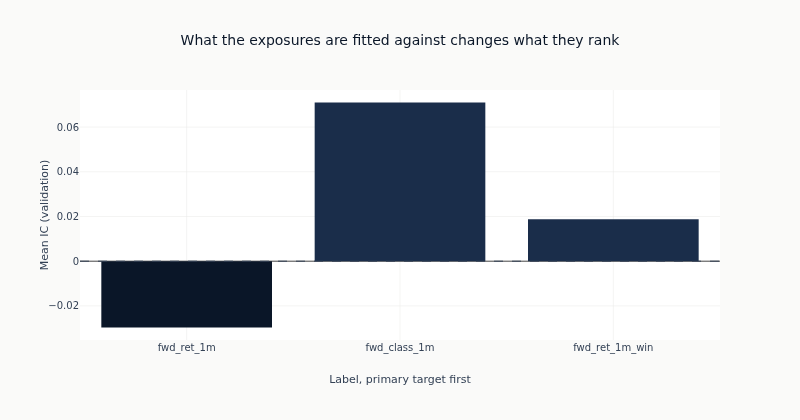

In [13]:
panel = catalog.with_columns(
    rank=pl.col("label").replace_strict(
        {label: index for index, label in enumerate(ordered_labels)}, return_dtype=pl.Int32
    )
).sort("rank")
fig = go.Figure(
    go.Bar(
        x=panel.get_column("label").to_list(),
        y=panel.get_column("ic_mean").to_list(),
        marker_color=[
            COLORS["blue"] if label == primary else COLORS["slate"]
            for label in panel.get_column("label")
        ],
        showlegend=False,
    )
)
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_yaxes(title_text="Mean IC (validation)")
fig.update_xaxes(title_text="Label, primary target first")
fig.update_layout(
    title="What the exposures are fitted against changes what they rank",
    height=420,
    width=800,
    margin=dict(t=90),
)
# Which side of zero each bar sits on is a fact about the frame, so the alt text reads it rather
# than asserting a shape the next run may not reproduce.
sides = "; ".join(
    f"{row['label']} {'above' if row['ic_mean'] > 0 else 'below'} zero"
    for row in panel.select("label", "ic_mean").iter_rows(named=True)
)
show_plotly_with_alt(
    fig,
    "Bar chart of mean validation information coefficient, one bar per label on one axis, with the "
    "primary target in dark navy first and the two variants in slate, and a dashed zero line. "
    f"Counted from the frame: {sides}.",
)

## 5. What to notice

**The estimator is the same and only the target moves, which is what makes these three rows
comparable.** They share the characteristics, the folds, the months scored and the factor count.
`fwd_ret_1m_win` is `fwd_ret_1m` with each month's cross-section clipped at its own tails, so a
gap between those two rows is a statement about the tails and nothing else - the same controlled
comparison [`06_gbm`](06_gbm.ipynb) made by varying the loss instead of the target. `fwd_class_1m`
is a third reading: the exposures are fitted against a class rather than a magnitude, and the IC
is still measured against the continuous return the class was cut from.

**A model with no epochs still has a checkpoint, and the checkpoint is not a formality.** The
registry keys a prediction set on `(training identity, checkpoint)`, so a family whose members
publish 1, 5 and 10 checkpoints each needs one convention rather than three. IPCA publishes at 0
because alternating least squares runs to convergence: there is no intermediate state a reader
could have stopped at, and pretending otherwise would invent a choice the estimator does not
offer. [`08b_conditional_autoencoder`](08b_conditional_autoencoder.ipynb) is the contrast, where
the stopping point is real and is published.

**What IPCA buys over predicting the return directly is a constraint, not more capacity.** The
linear models in [`05_linear`](05_linear.ipynb) had 57 free weights and one month of
cross-section to find them in. IPCA has a map from 57 characteristics to `n_factors` exposures,
shared by every firm and every month, and the factor returns are then whatever best explains that
month given those exposures. That is far fewer free parameters against far more data, and it is
the entire argument for the family. It is also its limitation: if the relationship between a
characteristic and its exposure is not linear, the constraint is wrong rather than merely tight,
which is what [`08b_conditional_autoencoder`](08b_conditional_autoencoder.ipynb) relaxes.

**None of this selects anything.** IC measures whether predictions rank firms correctly, not
whether a strategy trading them makes money after costs and turnover, and every label's
prediction set stays in the published population for that reason. Selection is on validation
backtest Sharpe in [`11_backtest`](11_backtest.ipynb).

**Known limitations.** The number of factors is declared rather than chosen, and nothing here
tests whether a different count would order the cross-section better - that would be a search,
and a search over validation IC is the thing this notebook is arranged to avoid. The ridge
penalties on both least-squares steps are declared the same way. IPCA assumes exposures are
linear in the characteristics and constant within a month, and this panel's anonymous
split-scoped firm identities mean the universe cannot be reconstructed to check what a firm's
exposure history looks like across blocks. And every number is measured on validation folds that
have been read many times over by the time a case study reaches this notebook.

**Next**: [`08b_conditional_autoencoder`](08b_conditional_autoencoder.ipynb) keeps this exact
structure - characteristics to exposures, exposures times factor returns - and replaces the
linear map with a neural network, so the difference between the two is the shape of one function
and nothing else.